In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import pearsonr

from sst_pix2pix_annual_cycle import Generator, rollout_prediction, get_seasonal_encoding
from train_cmip6_sst import denormalize_data, load_and_process_cmip6_data, load_and_process_cmip6_anomaly_data
from utils import save_rollout_to_netcdf_new,save_rollout_to_netcdf

In [2]:
# ============================================================================
# Load Trained Model
# ============================================================================

def load_trained_model(checkpoint_path, device='cpu'):
    """
    Load trained generator from checkpoint.
    
    Args:
        checkpoint_path: Path to checkpoint file
        device: 'cuda' or 'cpu'
    
    Returns:
        generator, climatology, norm_params, num_input_months
    """
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    num_input_months = checkpoint['num_input_months']
    in_channels = num_input_months + 2
    
    generator = Generator(in_channels=in_channels, features=128, out_channels=1).to(device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    generator.eval()
    
    #climatology = checkpoint['climatology']
    norm_params = checkpoint['norm_params']
    
    print(f"Model loaded from epoch {checkpoint['epoch']}")
    if 'best_val_loss' in checkpoint:
        print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
    
    return generator, norm_params, num_input_months



In [3]:
# ============================================================================
# Evaluation Functions
# ============================================================================

def evaluate_rollout(generator, test_data, test_months, num_input_months, 
                     climatology, norm_params, num_rollout_months=24, 
                     num_rollouts=10, device='cuda'):
    """
    Evaluate multi-month rollout predictions.
    
    Args:
        generator: trained generator
        test_data: test SST data (normalized)
        test_months: month indices
        num_input_months: number of input months
        climatology: monthly climatology
        norm_params: normalization parameters
        num_rollout_months: how many months to predict
        num_rollouts: how many different starting points to test
        device: computation device
    
    Returns:
        rollout results and metrics
    """
    print("\n" + "="*70)
    print(f"Evaluating {num_rollout_months}-Month Rollout Predictions")
    print("="*70)
    
    all_rollout_predictions = []
    all_rollout_targets = []
    
    print("length of test data: "+str(len(test_data)))

    # Perform multiple rollouts from different starting points
    step_size = max(1, (len(test_data) - num_input_months - num_rollout_months) // num_rollouts)
    
    for i in range(num_rollouts):
        start_idx = num_input_months + i * step_size
        
        # if start_idx + num_rollout_months >= len(test_data):
        #     break
        
        # Get initial inputs
        initial_inputs = torch.FloatTensor(test_data[start_idx-num_input_months:start_idx])
        initial_month = test_months[start_idx - 1]
        
        # Perform rollout
        predictions = rollout_prediction(
            generator, initial_inputs, initial_month, 
            num_months=num_rollout_months
        )
        
        # # Get ground truth
        # targets = test_data[start_idx:start_idx+num_rollout_months]
        
        all_rollout_predictions.append(np.array(predictions))
        # all_rollout_targets.append(targets)
    
    # Convert to arrays
    rollout_predictions = np.array(all_rollout_predictions)  # (num_rollouts, num_months, 48, 144)
    #rollout_targets = np.array(all_rollout_targets)
    
    # Denormalize
    rollout_predictions = denormalize_data(rollout_predictions, norm_params)
    # rollout_targets = denormalize_data(rollout_targets, norm_params)
    
    
    
    # Check annual cycle preservation
    if num_rollout_months >= 24:
        year1_preds = rollout_predictions[:, 0:12].mean(axis=(0, 2, 3))
        year2_preds = rollout_predictions[:, 12:24].mean(axis=(0, 2, 3))
        cycle_correlation = pearsonr(year1_preds, year2_preds)[0]
        print(f"\nAnnual cycle consistency (year 1 vs year 2): {cycle_correlation:.4f}")
    
    results = {
        'predictions': rollout_predictions,
        
    }
    
    return results



In [4]:
from scipy.signal import detrend
def process_with_detrending(data, detrend_type='linear'):
    """
    Optional: Apply detrending to SST data.
    
    Args:
        data: SST data (time, lat, lon)
        detrend_type: 'linear' or 'constant'
    
    Returns:
        detrended data
    """
    if detrend_type is None:
        return data
    
    print(f"Applying {detrend_type} detrending...")
    data_detrended = np.zeros_like(data)
    
    # Detrend along time axis for each spatial point
    for i in range(data.shape[1]):
        for j in range(data.shape[2]):
            data_detrended[:, i, j] = detrend(data[:, i, j], type=detrend_type)
    
    return data_detrended


def normalize_data(train_data, val_data, test_data, method='standardize'):
    """
    Normalize SST data.
    
    Args:
        train_data, val_data, test_data: SST arrays
        method: 'standardize' (z-score) or 'minmax' (0-1 scaling)
    
    Returns:
        normalized data and normalization parameters
    """
    if method == 'standardize':
        mean = np.mean(train_data)
        std = np.std(train_data)
        
        train_norm = (train_data - mean) / std
        val_norm = (val_data - mean) / std
        test_norm = (test_data - mean) / std
        
        norm_params = {'mean': mean, 'std': std, 'method': 'standardize'}
        
        print(f"Standardization - Mean: {mean:.4f}, Std: {std:.4f}")
        
    elif method == 'minmax':
        min_val = np.min(train_data)
        max_val = np.max(train_data)
        
        train_norm = (train_data - min_val) / (max_val - min_val)
        val_norm = (val_data - min_val) / (max_val - min_val)
        test_norm = (test_data - min_val) / (max_val - min_val)
        
        norm_params = {'min': min_val, 'max': max_val, 'method': 'minmax'}
        
        print(f"Min-Max scaling - Min: {min_val:.4f}, Max: {max_val:.4f}")
    
    else:
        # No normalization
        train_norm, val_norm, test_norm = train_data, val_data, test_data
        norm_params = {'method': 'none'}
    
    return train_norm, val_norm, test_norm, norm_params



In [5]:
lon_sst=np.array([  0.      ,   2.493056,   4.986111,   7.479167,   9.972222,  12.465278,
        14.958333,  17.451389,  19.944444,  22.4375  ,  24.930556,  27.423611,
        29.916667,  32.409722,  34.902778,  37.395833,  39.888889,  42.381944,
        44.875   ,  47.368056,  49.861111,  52.354167,  54.847222,  57.340278,
        59.833333,  62.326389,  64.819444,  67.3125  ,  69.805556,  72.298611,
        74.791667,  77.284722,  79.777778,  82.270833,  84.763889,  87.256944,
        89.75    ,  92.243056,  94.736111,  97.229167,  99.722222, 102.215278,
       104.708333, 107.201389, 109.694444, 112.1875  , 114.680556, 117.173611,
       119.666667, 122.159722, 124.652778, 127.145833, 129.638889, 132.131944,
       134.625   , 137.118056, 139.611111, 142.104167, 144.597222, 147.090278,
       149.583333, 152.076389, 154.569444, 157.0625  , 159.555556, 162.048611,
       164.541667, 167.034722, 169.527778, 172.020833, 174.513889, 177.006944,
       179.5     , 181.993056, 184.486111, 186.979167, 189.472222, 191.965278,
       194.458333, 196.951389, 199.444444, 201.9375  , 204.430556, 206.923611,
       209.416667, 211.909722, 214.402778, 216.895833, 219.388889, 221.881944,
       224.375   , 226.868056, 229.361111, 231.854167, 234.347222, 236.840278,
       239.333333, 241.826389, 244.319444, 246.8125  , 249.305556, 251.798611,
       254.291667, 256.784722, 259.277778, 261.770833, 264.263889, 266.756944,
       269.25    , 271.743056, 274.236111, 276.729167, 279.222222, 281.715278,
       284.208333, 286.701389, 289.194444, 291.6875  , 294.180556, 296.673611,
       299.166667, 301.659722, 304.152778, 306.645833, 309.138889, 311.631944,
       314.125   , 316.618056, 319.111111, 321.604167, 324.097222, 326.590278,
       329.083333, 331.576389, 334.069444, 336.5625  , 339.055556, 341.548611,
       344.041667, 346.534722, 349.027778, 351.520833, 354.013889, 356.506944])

lat_sst=np.array([-8.950000e+01, -8.577083e+01, -8.204167e+01, -7.831250e+01,
       -7.458333e+01, -7.085417e+01, -6.712500e+01, -6.339583e+01,
       -5.966667e+01, -5.593750e+01, -5.220833e+01, -4.847917e+01,
       -4.475000e+01, -4.102083e+01, -3.729167e+01, -3.356250e+01,
       -2.983333e+01, -2.610417e+01, -2.237500e+01, -1.864583e+01,
       -1.491667e+01, -1.118750e+01, -7.458333e+00, -3.729167e+00,
        1.136868e-13,  3.729167e+00,  7.458333e+00,  1.118750e+01,
        1.491667e+01,  1.864583e+01,  2.237500e+01,  2.610417e+01,
        2.983333e+01,  3.356250e+01,  3.729167e+01,  4.102083e+01,
        4.475000e+01,  4.847917e+01,  5.220833e+01,  5.593750e+01,
        5.966667e+01,  6.339583e+01,  6.712500e+01,  7.085417e+01,
        7.458333e+01,  7.831250e+01,  8.204167e+01,  8.577083e+01])

In [6]:
#!pip install basemap
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='seismic')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



In [7]:
# ============================================================================
# Visualization Functions
# ============================================================================


def plot_rollout(rollout_results, start_month=0, 
                            save_path='rollout_comparison.png'):
    """Plot rollout predictions for a full year."""
    #predictions = rollout_results['predictions'][0, :12]  # First rollout, 12 months
    predictions = rollout_results['predictions'][0, :]  # First rollout, all months
    yr = int(predictions.shape[0] // 12)
    predictions=predictions.reshape(yr, 12, 48, 144).mean(axis=0)
    print(rollout_results['predictions'].shape)
    
    for i in range(12):
        print('Month: '+str(i+1))
        plot_map(lon_sst,lat_sst,rollout_results['predictions'][0, i],'../../Data/output/Temp/seasonal_pattern'+str(i+1)+'.png')




In [8]:
def load_and_process_cmip6_data(dataset_path, mask_path='../../Data/mask.npy', 
                                 n_train=1428, n_val=100, ensemble_id=0):
    """
    Load and process CMIP6 SST data.
    
    Args:
        dataset_path: Path to CMIP6 netCDF file
        mask_path: Path to mask file
        n_train: Number of training samples
        n_val: Number of validation samples
        ensemble_id: Which ensemble member to use (if multiple)
    
    Returns:
        train_data, val_data, test_data, train_months, val_months, test_months, mask
    """
    print(f"Loading dataset from: {dataset_path}")
    
    # Load dataset
    ds = xr.open_dataset(dataset_path)
    
    # Select SST variable
    sst = ds["sst"]
    
    # If multiple ensembles, select one
    if "ensemble" in sst.dims:
        print(f"Multiple ensembles found. Selecting ensemble {ensemble_id}")
        sst = sst.isel(ensemble=ensemble_id)
    
    # Fill NaN values with 0
    sst = sst.fillna(0)
    
    sst = sst - sst.mean(dim="years")  # Center data by removing mean over time

    # Stack years and months into time dimension
    sst_time = (
        sst
        .stack(time=("years", "mon"))
        .transpose("time", "lat", "lon")
    ).fillna(0)
    
    data = sst_time.values  # Shape: (time, lat, lon)
    
    print(f"Data shape: {data.shape}")
    print(f"Data range: [{data.min():.2f}, {data.max():.2f}]")
    
    # Load mask
    mask = np.load(mask_path)
    print(f"Mask shape: {mask.shape}")
    
    # Split data
    train_data = data[:n_train, :, :]
    val_data = data[n_train:n_train + n_val, :, :]
    test_data = data[n_train:, :, :]
    
    print(f"Train shape: {train_data.shape}")
    print(f"Val shape: {val_data.shape}")
    print(f"Test shape: {test_data.shape}")
    
    # Create month arrays (0-11 for each sample)
    # Assuming data starts from a known month, or extract from dataset
    # If your dataset has months encoded, extract them. Otherwise:
    total_samples = data.shape[0]
    
    # Try to get starting month from dataset metadata
    if 'mon' in ds.coords:
        # If months are in coordinates, use them
        months_all = np.array([(i % 12) for i in range(total_samples)])
    else:
        # Default: assume data starts in January (month 0)
        months_all = np.array([i % 12 for i in range(total_samples)])
    
    train_months = months_all[:n_train]
    val_months = months_all[n_train:n_train + n_val]
    test_months = months_all[n_train:]
    
    return train_data, val_data, test_data, train_months, val_months, test_months, mask


Loading checkpoint from: ./checkpoints_EC_Earth3_CC_anomaly/checkpoint_epoch_200.pth
Model loaded from epoch 199
Loading dataset from: ../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc
Multiple ensembles found. Selecting ensemble 0
Data shape: (1980, 48, 144)
Data range: [-11.41, 10.61]
Mask shape: (48, 144)
Train shape: (1428, 48, 144)
Val shape: (100, 48, 144)
Test shape: (552, 48, 144)
Applying linear detrending...
Standardization - Mean: -0.0000, Std: 0.5656

Evaluating 6000-Month Rollout Predictions
length of test data: 552

Annual cycle consistency (year 1 vs year 2): 0.6007
(1, 6000, 48, 144)
Month: 1


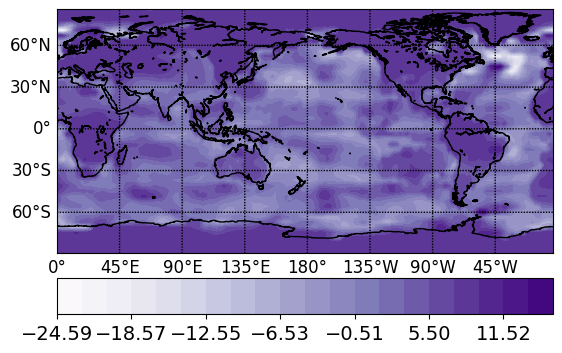

Month: 2


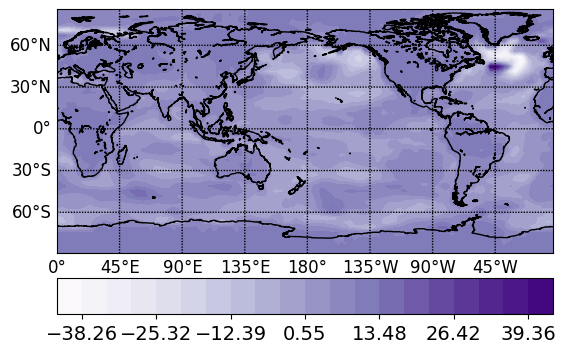

Month: 3


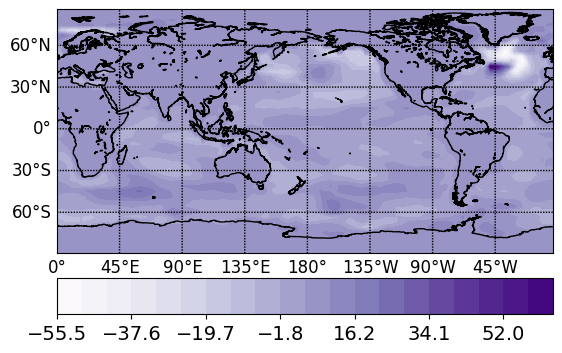

Month: 4


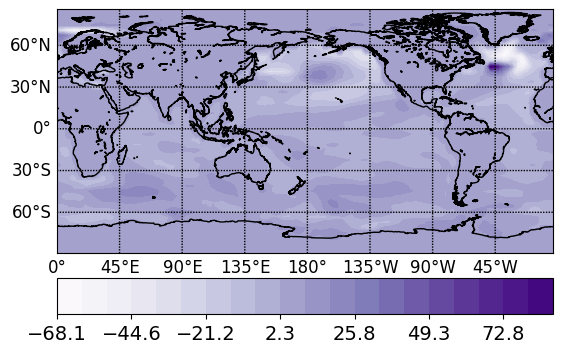

Month: 5


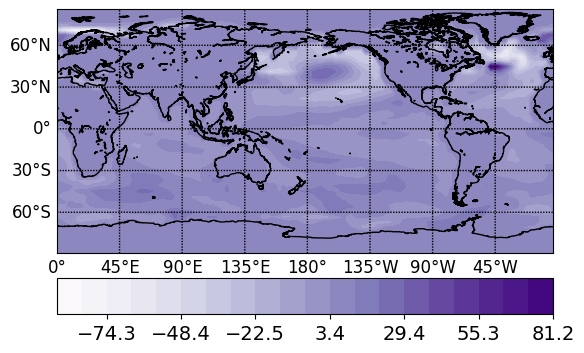

Month: 6


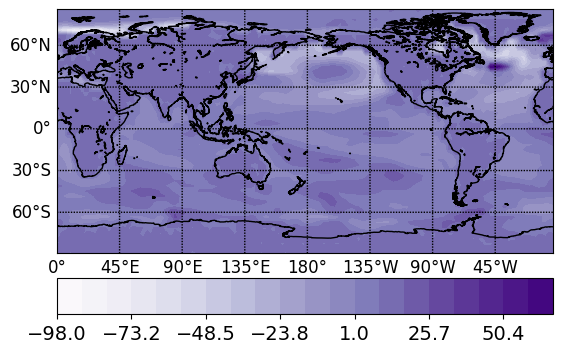

Month: 7


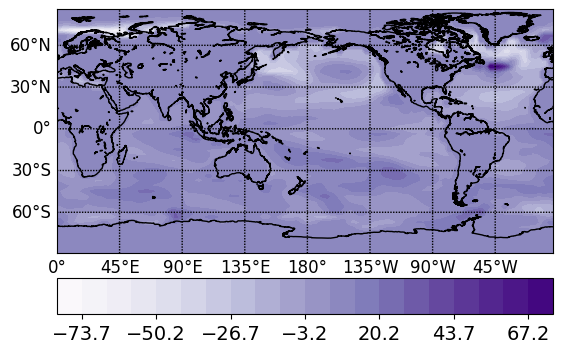

Month: 8


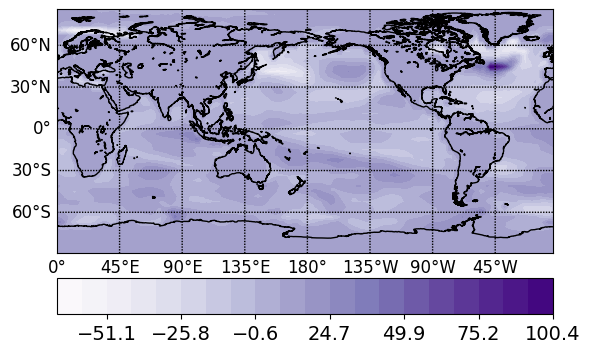

Month: 9


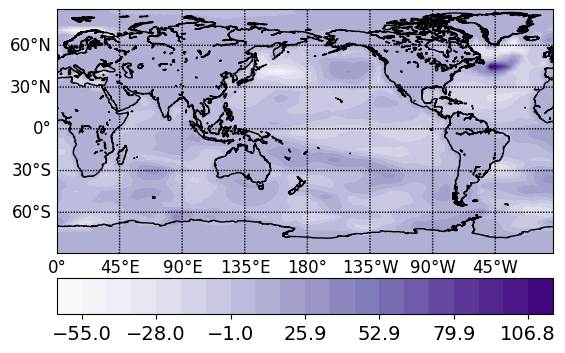

Month: 10


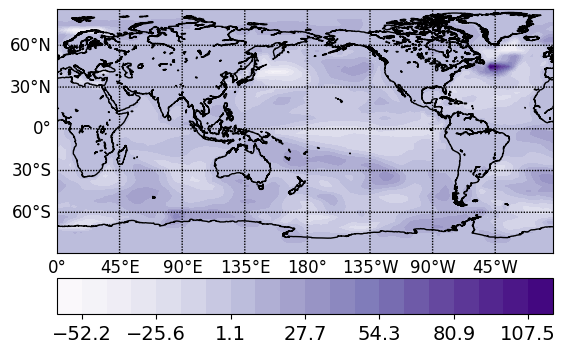

Month: 11


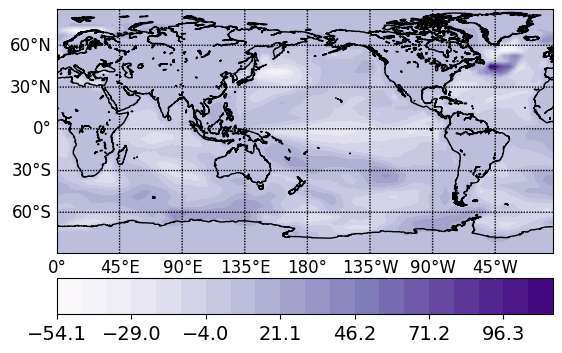

Month: 12


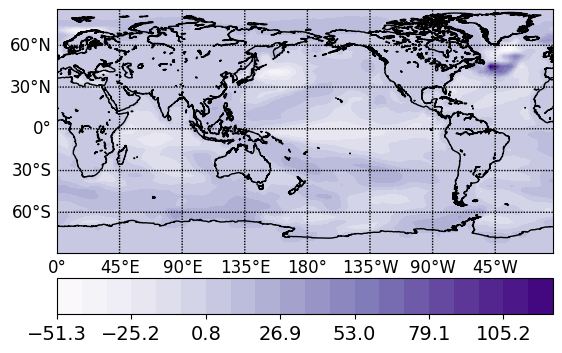


Evaluation Complete!

Generated files:


<Figure size 640x480 with 0 Axes>

In [17]:
# ============================================================================
# Main Test Script
# ============================================================================


"""Main testing and evaluation script."""

# Configuration
#CHECKPOINT_PATH = './checkpoints_EC_Earth3_CC_anomaly/checkpoint_epoch_200.pth'
#CHECKPOINT_PATH = './checkpoints_EC_Earth3_CC_anomaly_ewc/ensemble_2/checkpoint_epoch_50.pth'
CHECKPOINT_PATH = './checkpoints_EC_Earth3_CC_anomaly/checkpoint_epoch_200.pth'
# DATASET_PATH = '../../Data/CMIP6-SST/GISS-E2-1-H_historical_1850_2014.nc'
DATASET_PATH = '../../Data/CMIP6-SST/EC_Earth3_CC_historical_1850_2014.nc'
# DATASET_PATH = '../../Data/CMIP6-SST/MIROC6_historical_1850_2014.nc'
MASK_PATH = '../../Data/mask.npy'
N_TRAIN = 1428
N_VAL = 100
ENSEMBLE_ID = 0

device = 'cuda' #if torch.cuda.is_available() else 'cpu'

# Load model
generator, norm_params, num_input_months = load_trained_model(
    CHECKPOINT_PATH, device
)

# Load test data
_, _, test_data, _, _, test_months, mask = load_and_process_cmip6_data(
    DATASET_PATH, MASK_PATH, N_TRAIN, N_VAL, ENSEMBLE_ID
)

test_data = process_with_detrending(test_data, 'linear')

# Normalize test data with same parameters
from train_cmip6_sst import normalize_data
_, _, test_data_norm, _ = normalize_data(
    test_data, test_data, test_data, method=norm_params['method']
)

if norm_params['method'] == 'standardize':
    test_data_norm = (test_data - norm_params['mean']) / norm_params['std']
elif norm_params['method'] == 'minmax':
    test_data_norm = (test_data - norm_params['min']) / (norm_params['max'] - norm_params['min'])
else:
    test_data_norm = test_data

# 2. Rollout evaluation
rollout_results = evaluate_rollout(
    generator, test_data_norm, test_months, num_input_months,
    None, norm_params, num_rollout_months=6000, num_rollouts=1, device=device
)

plot_rollout(rollout_results)
#plot_error_vs_lead_time(rollout_results)

print("\n" + "="*70)
print("Evaluation Complete!")
print("="*70)
print("\nGenerated files:")

#print("  - rollout_comparison.png")



In [18]:
# squeeze out the singleton rollout dimension
data = rollout_results['predictions'].squeeze()      # (time, lat, lon)
save_rollout_to_netcdf_new(data, lat_sst, lon_sst, '../../Data/output/EC_Earth3_CC/Updated/rollout_pred_ec_base_500yrs.nc')

PermissionError: [Errno 13] Permission denied: b'/home/deepayan/GAN/Data/output/EC_Earth3_CC/Updated/rollout_pred_ec_base_500yrs.nc'

In [19]:
save_rollout_to_netcdf(test_data_norm, lat_sst, lon_sst, '../../Data/output/EC_Earth3_CC/Updated/EC_e2_model_data.nc')

PermissionError: [Errno 13] Permission denied: b'/home/deepayan/GAN/Data/output/EC_Earth3_CC/Updated/EC_e2_model_data.nc'

In [19]:
import xarray as xr
rollout = xr.open_dataset('../../Data/output/EC_Earth3_CC/Updated/rollout_pred_ec_base_500yrs.nc')
ori_test = xr.open_dataset('../../Data/output/EC_Earth3_CC/Updated/EC_e1_model_data.nc')
obs_test = xr.open_dataset('../../Data/output/Observed/Updated/cobe.nc')

/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/deepayan/anaconda3/envs/test/lib/python3.9/site-packages/xarray/core/indexing.py:526: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(self.get_duck_array(), dtype=dtype)


Text(0.5, 1.0, 'MSE between Observed and Original/Generated SST')

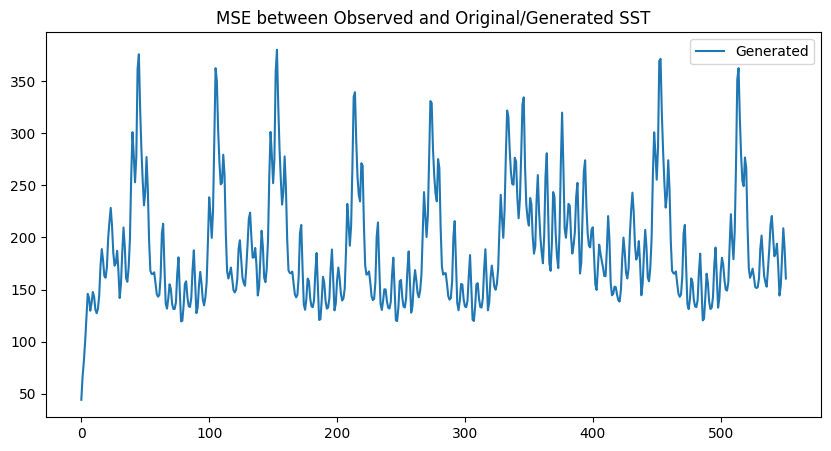

In [20]:
obs_test.sst.values[0].shape
ori_test.sst.values[0].shape

from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

mse_ori=[]
mse_gen=[]
for i in range(ori_test.sst.values.shape[0]):
    
    mse_ori.append(mean_squared_error(obs_test.sst.values[i],ori_test.sst.values[i]))
    mse_gen.append(mean_squared_error(obs_test.sst.values[i],rollout.sst.values[i]))

plt.figure(figsize=(10,5))
#plt.plot(mse_ori,label='Original')
plt.plot(mse_gen,label='Generated')
plt.legend()
plt.title('MSE between Observed and Original/Generated SST')

In [37]:
obs_aligned

<xarray.DataArray 'sst' (time: 552, lat: 48, lon: 144)> Size: 15MB
array([[[-0.812557, -0.812557, ..., -0.812557, -0.812557],
        [-0.812557, -0.812557, ..., -0.812557, -0.812557],
        ...,
        [-0.811496, -0.811476, ..., -0.811659, -0.81156 ],
        [-0.812268, -0.812321, ..., -0.812389, -0.812276]],

       [[-0.812557, -0.812557, ..., -0.812557, -0.812557],
        [-0.812557, -0.812557, ..., -0.812557, -0.812557],
        ...,
        [-0.811847, -0.811892, ..., -0.811973, -0.811988],
        [-0.81223 , -0.812377, ..., -0.812258, -0.812362]],

       ...,

       [[-0.812557, -0.812557, ..., -0.812557, -0.812557],
        [-0.812557, -0.812557, ..., -0.812557, -0.812557],
        ...,
        [-0.799805, -0.798341, ..., -0.802925, -0.801348],
        [-0.806746, -0.806723, ..., -0.80732 , -0.807018]],

       [[-0.812557, -0.812557, ..., -0.812557, -0.812557],
        [-0.812557, -0.812557, ..., -0.812557, -0.812557],
        ...,
        [-0.801639, -0.800667, ..., -0.804152, -0.802891],
        [-0.809632, -0.80951 , ..., -0.809886, -0.809708]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1971-01-01 1971-02-01 ... 2016-12-01
  * lat      (lat) float64 384B -89.5 -85.77 -82.04 -78.31 ... 78.31 82.04 85.77
  * lon      (lon) float64 1kB 0.0 2.493 4.986 7.479 ... 349.0 351.5 354.0 356.5

Correlation map shape: (48, 144)
<xarray.DataArray 'sst' (lat: 48, lon: 144)> Size: 28kB
array([[-3.3936514e-05, -5.5237779e-06, -3.2456737e-05, ...,
         5.6699747e-07,  1.6271682e-05,  3.7209929e-06],
       [-1.2875325e-06, -4.0332434e-05,  1.5905613e-05, ...,
         3.6521255e-06,  3.1361691e-05, -3.6465026e-06],
       [-2.2059920e-05, -3.9949355e-05, -3.6473048e-06, ...,
        -4.2511047e-06,  1.0250321e-06, -2.2330480e-05],
       ...,
       [-2.8260969e-02, -9.7403890e-03, -4.6238489e-02, ...,
        -3.9950136e-02, -1.7235383e-03, -2.2140577e-02],
       [-3.7848607e-02, -4.0853780e-02, -8.0568664e-02, ...,
        -2.5204459e-02,  5.2160598e-02, -2.7433651e-02],
       [-1.0206534e-02, -1.8717358e-02,  3.2093719e-02, ...,
        -1.1428161e-02, -2.6982117e-03, -3.4351744e-02]], dtype=float32)
Coordinates:
  * lat      (lat) float64 384B -89.5 -85.77 -82.04 -78.31 ... 78.31 82.04 85.77
  * lon      (lon) float64 1kB 0.0 2.493 4.986 7.479 ... 349.0 351.5 354.0 356.5


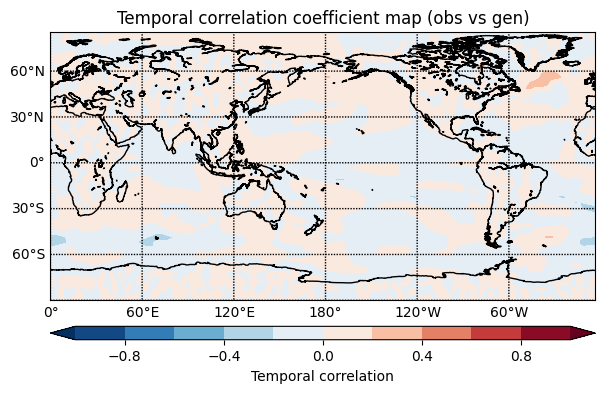

Mean Correlation (obs vs gen): 0.03876521


In [21]:
# align obs and ori over common time range
obs_aligned = obs_test.sst.sel(time=ori_test.time)  # keep same time steps as ori_test
ori_aligned = ori_test.sst
gen_aligned = rollout.sst.sel(time=ori_test.time)

# temporal correlation map (lat, lon)
corr_map = xr.corr(obs_aligned, gen_aligned, dim="time")

print("Correlation map shape:", corr_map.shape)
print(corr_map)

# optional: visualize
plt.figure(figsize=(10,4))
m = Basemap(projection='cyl',
            llcrnrlon=lon_sst.min(), urcrnrlon=lon_sst.max(),
            llcrnrlat=lat_sst.min(), urcrnrlat=lat_sst.max(),
            resolution='l')
lons, lats = np.meshgrid(lon_sst, lat_sst)
x, y = m(lons, lats)
cs = m.contourf(x, y, corr_map.values, levels=np.linspace(-1,1,11), cmap='RdBu_r', extend='both')
m.drawcoastlines()
m.drawparallels(np.arange(-90,91,30), labels=[1,0,0,0])
m.drawmeridians(np.arange(0,361,60), labels=[0,0,0,1])
cb = m.colorbar(cs, "bottom", size="5%", pad="10%")
cb.set_label("Temporal correlation")
plt.title("Temporal correlation coefficient map (obs vs gen)")
plt.show()

print("Mean Correlation (obs vs gen):", abs(corr_map.values).mean())

Correlation map shape: (48, 144)
<xarray.DataArray 'sst' (lat: 48, lon: 144)> Size: 55kB
array([[ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00, ...,
         1.00000000e+00,  1.00000000e+00,  1.00000000e+00],
       ...,
       [-2.32786493e-02,  2.96750582e-02,  6.41150656e-02, ...,
        -1.41098303e-01, -1.17019370e-01, -7.68160220e-02],
       [ 1.29996722e-02,  2.65108480e-02,  4.31281053e-02, ...,
         6.24953081e-04, -1.21324748e-03,  2.69449399e-04],
       [ 2.24808962e-01,  2.23055512e-01,  2.21646675e-01, ...,
         2.37689523e-01,  2.31494444e-01,  2.28616772e-01]])
Coordinates:
  * lat      (lat) float64 384B -89.5 -85.77 -82.04 -78.31 ... 78.31 82.04 85.77
  * lon      (lon) float64 1kB 0.0 2.493 4.986 7.479 ... 349

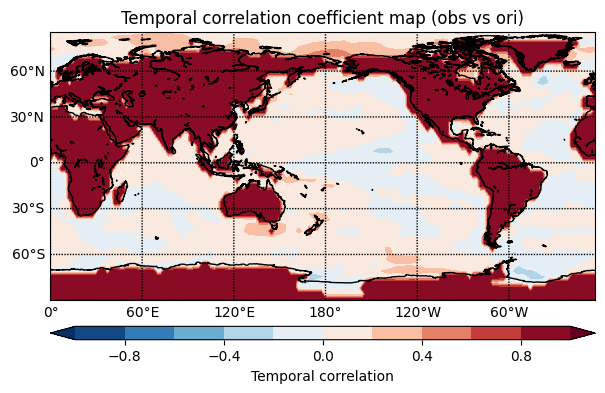

Mean Correlation (obs vs ori): 0.4022668035494074


In [22]:
# align obs and ori over common time range
obs_aligned = obs_test.sst.sel(time=ori_test.time)  # keep same time steps as ori_test
ori_aligned = ori_test.sst
gen_aligned = rollout.sst.sel(time=ori_test.time)

# temporal correlation map (lat, lon)
corr_map = xr.corr(obs_aligned, ori_aligned, dim="time")

print("Correlation map shape:", corr_map.shape)
print(corr_map)

# optional: visualize
plt.figure(figsize=(10,4))
m = Basemap(projection='cyl',
            llcrnrlon=lon_sst.min(), urcrnrlon=lon_sst.max(),
            llcrnrlat=lat_sst.min(), urcrnrlat=lat_sst.max(),
            resolution='l')
lons, lats = np.meshgrid(lon_sst, lat_sst)
x, y = m(lons, lats)
cs = m.contourf(x, y, corr_map.values, levels=np.linspace(-1,1,11), cmap='RdBu_r', extend='both')
m.drawcoastlines()
m.drawparallels(np.arange(-90,91,30), labels=[1,0,0,0])
m.drawmeridians(np.arange(0,361,60), labels=[0,0,0,1])
cb = m.colorbar(cs, "bottom", size="5%", pad="10%")
cb.set_label("Temporal correlation")
plt.title("Temporal correlation coefficient map (obs vs ori)")
plt.show()
print("Mean Correlation (obs vs ori):", abs(corr_map.values).mean())

In [ ]:
rollout_results['predictions'].squeeze().shape

Generated


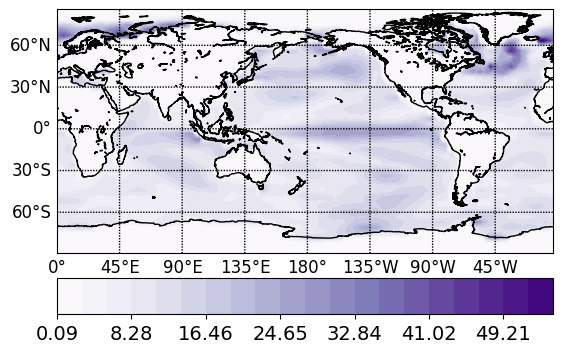

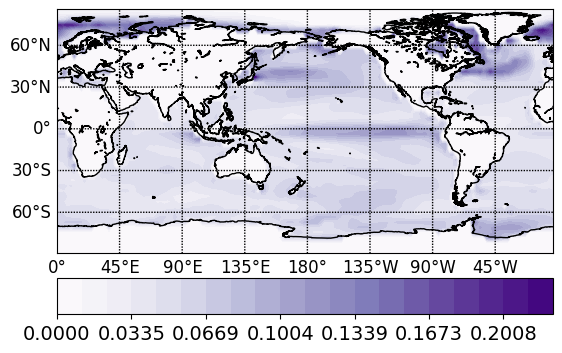

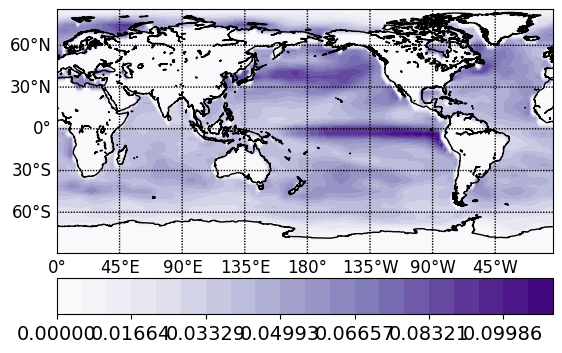

<Figure size 640x480 with 0 Axes>

In [23]:

def plot_map(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,7.0,11)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    temp = m.contourf(x,y,data,levels=levels,cmap='Purples')
    cb = m.colorbar(temp,"bottom", size="15%", pad="10%")
    cb.ax.tick_params(labelsize=14)  # Increase font size of colorbar ticks
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0], fontsize=12)
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1], fontsize=12)
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name,dpi=300,bbox_inches='tight')
    


    plt.show()
    plt.clf()

print('Generated')
plot_map(lon_sst,lat_sst,rollout.sst.std(axis=0),'std.png')
plot_map(lon_sst,lat_sst,ori_test.sst.std(axis=0),'std.png')
plot_map(lon_sst,lat_sst,obs_test.sst.std(axis=0),'std.png')

In [24]:
# -*- coding: utf-8 -*-
"""
Created on Sat Nov 20 22:18:26 2021

@author: Devabrat
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pylab as pl
from scipy import signal
import matplotlib.pyplot as plt
import scipy.stats
from netCDF4 import Dataset

def cal_power_spect(data):
    #data=N_EP_gen#np.loadtxt('iod.txt', dtype=np.float32)
    #data=data_whole.variables['temp'][:]
    #data=data.reshape(data.shape[0],)

    nd=len(data)


    nrho=len(data)
    rho=0
    sommesup=0
    sommeinf=0
    for i in range(1,nrho):
        j=i-1
        sommesup=sommesup+(data[i]*data[j])
        sommeinf=sommeinf+((data[j]**2))

    rho=sommesup/sommeinf

    nt=len(data)

    rzero=0
    redtab=[]
    red=[]

    srho=np.sqrt(1-rho**2)

    nsim=1500

    red_sum=np.zeros((nd, nsim))
    for i in range(nsim):
    
        white=srho*np.random.randn(1)
        red_sum[0,i]=rho*rzero+white
        
        for j in range(1,nd):
            white=srho*np.random.randn(1)
            red_sum[j,i]=rho*red_sum[j-1,i]+white
            
    redtab.append(red_sum)
        
    redtab=np.array(redtab)
    redtab=redtab.reshape(nd,nsim)


    fs=1
    f, Po = signal.periodogram(data, fs, detrend='linear')

    npo=len(Po)
    Po=Po.reshape(npo,)

    Ax=np.sum(Po)/npo

    red2=[]
    specred=np.zeros((npo,nsim))

    for i in range(nsim):
        red2=redtab[:,i]
        red2m=np.sum(red2)/nd
        red2n=red2-red2m
        fs=1
        fr, Pr = signal.periodogram(red2n, fs, detrend='linear')  #detrend = linear
        npr=len(Pr)
        Pr=Pr.reshape(npr,)
        
        Ar=np.sum(Pr)/npr
        Pr=Pr*(Ax/Ar)
        specred[:,i]=Pr
        
    Mpr=0
    Mspecred=[]
    for i in range(npr):
        Mpr=specred[i,1]
        for j in range(1,nsim):
            Mpr=Mpr+specred[i,j]
        
        Mpr=np.sum(Mpr)/nsim
        Mspecred.append(Mpr)

    Mspecred=np.array(Mspecred)


    period_Po=1/f
    period_Pr=1/fr


    n85=round(1500*85/100)
    n90=round(1500*90/100)
    n95=round(1500*95/100)
    n99=round(1500*99/100)


    tabvecsort=np.zeros((npr,nsim))
    for i in range(npr):
        vec=specred[i,:]
        tabvecsort[i,:]=np.sort(vec)
        
    tabMC=np.zeros((npr,4))

    for i in range(npr):
        tabMC[i,0]=tabvecsort[i,n85]
        tabMC[i,1]=tabvecsort[i,n90]
        tabMC[i,2]=tabvecsort[i,n95]
        tabMC[i,3]=tabvecsort[i,n99]
        

        
    plot=np.zeros((Po.shape[0],3), dtype=np.float32)

    plot[:,0]=period_Po
    plot[:,1]=f*Po
    plot[:,2]=f*tabMC[:,2]
    return plot





Generated


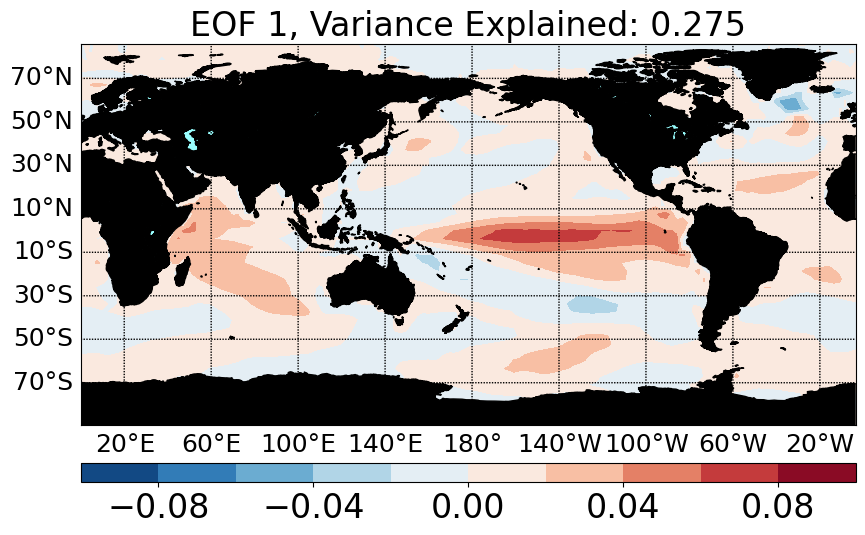

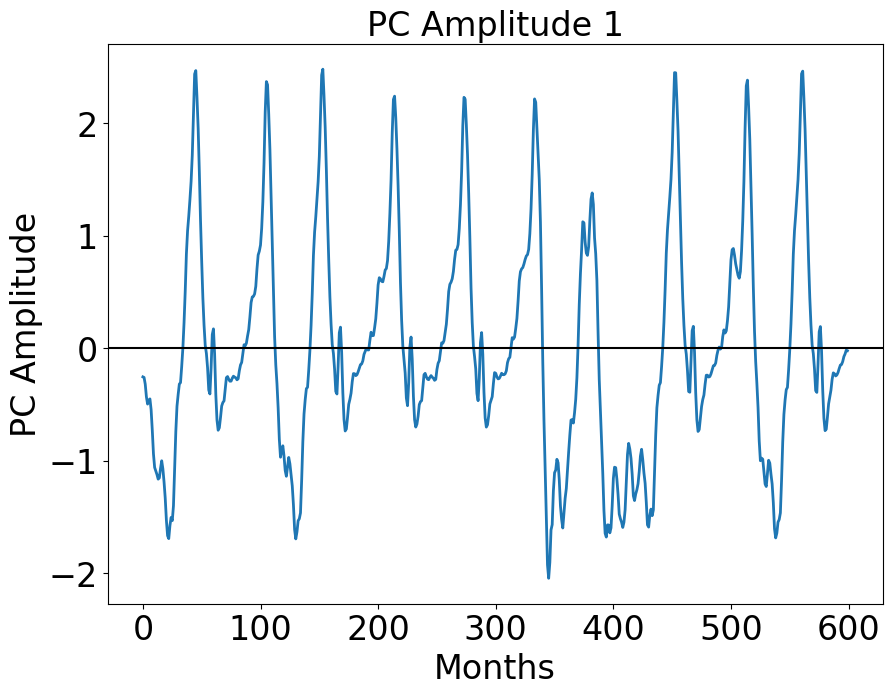

/tmp/ipykernel_2897038/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_2897038/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


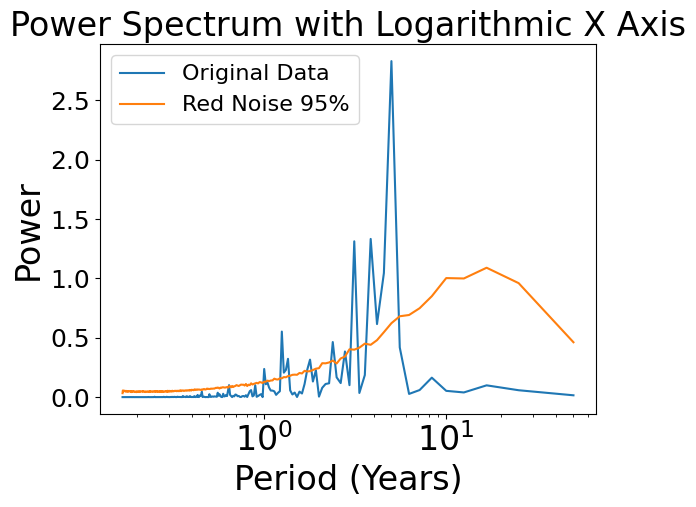

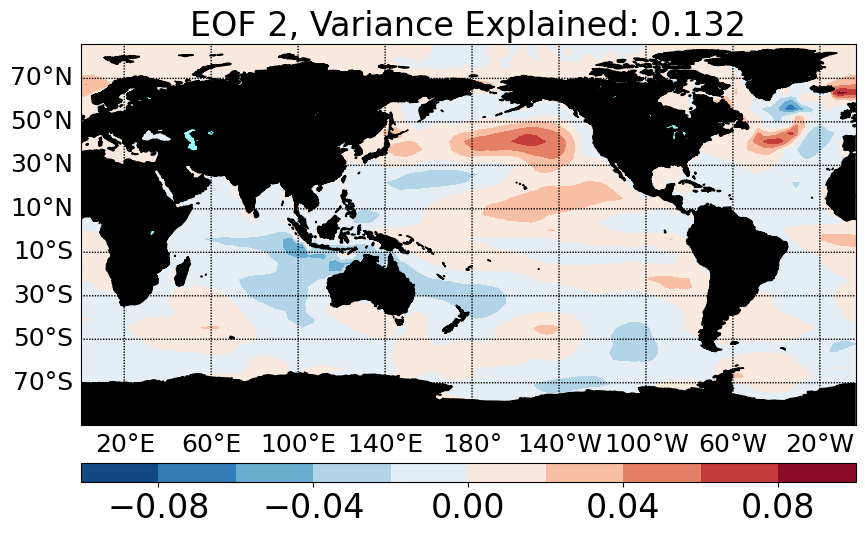

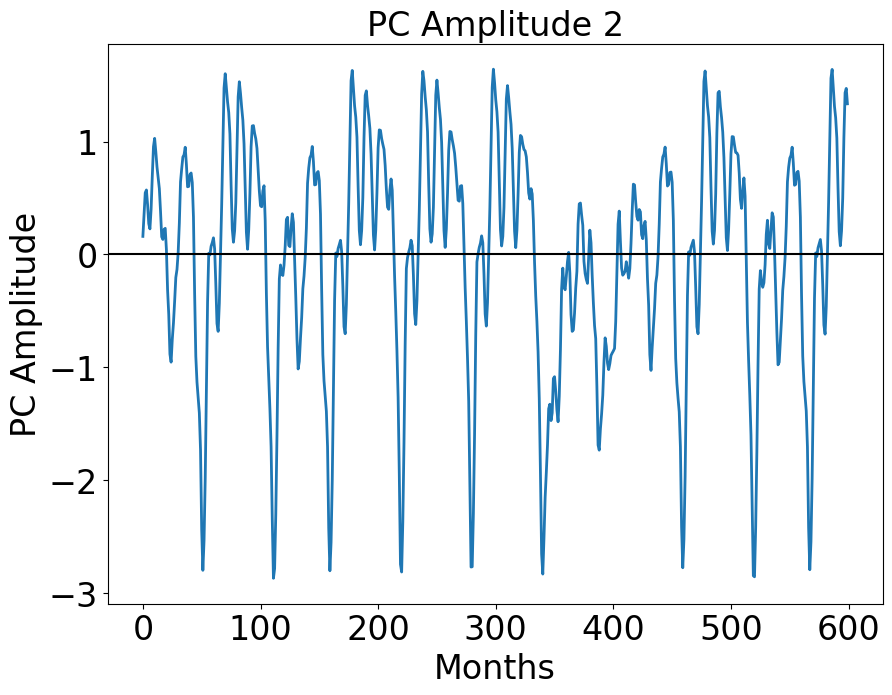

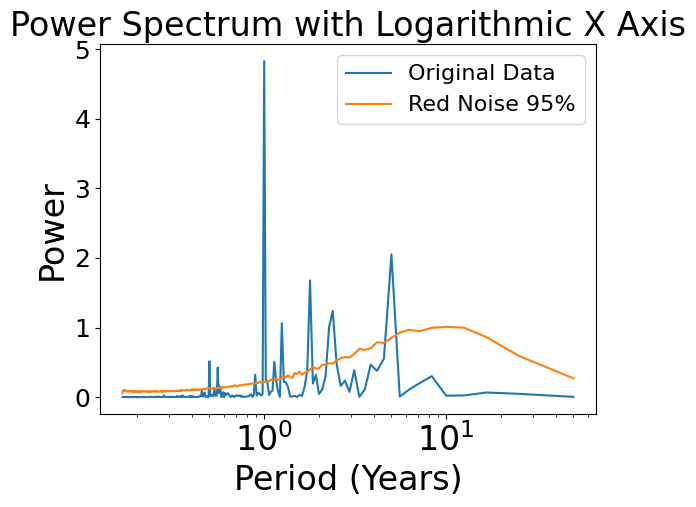

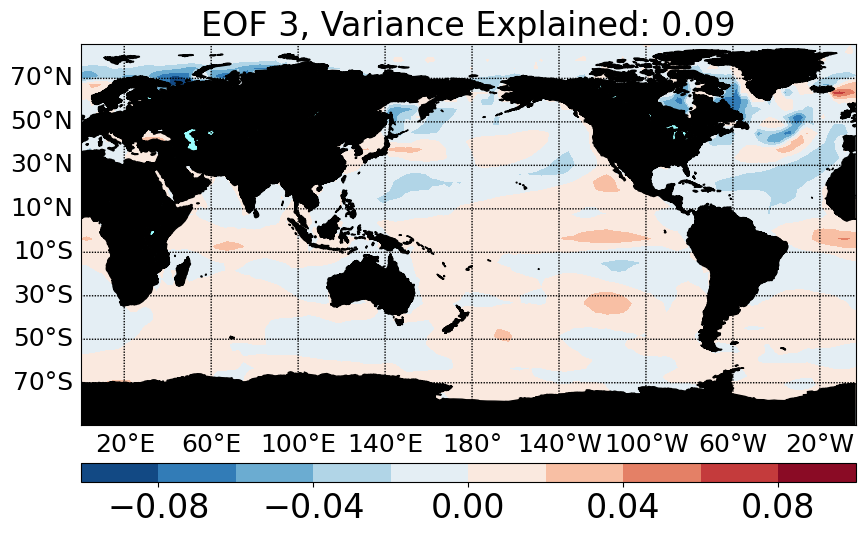

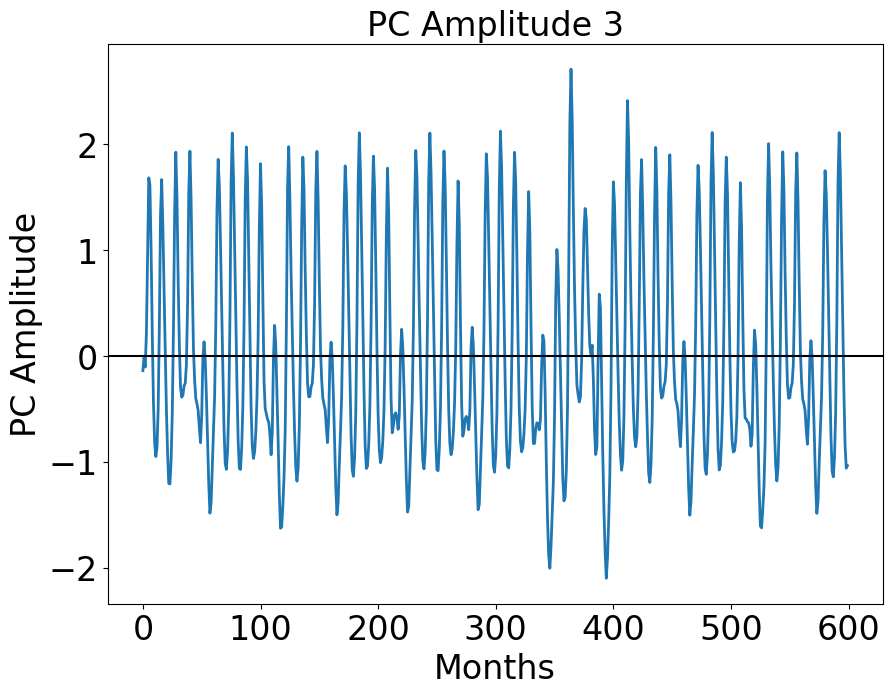

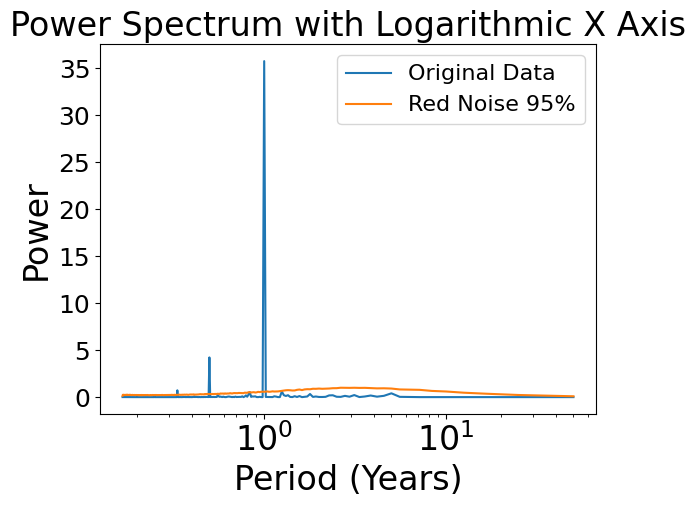

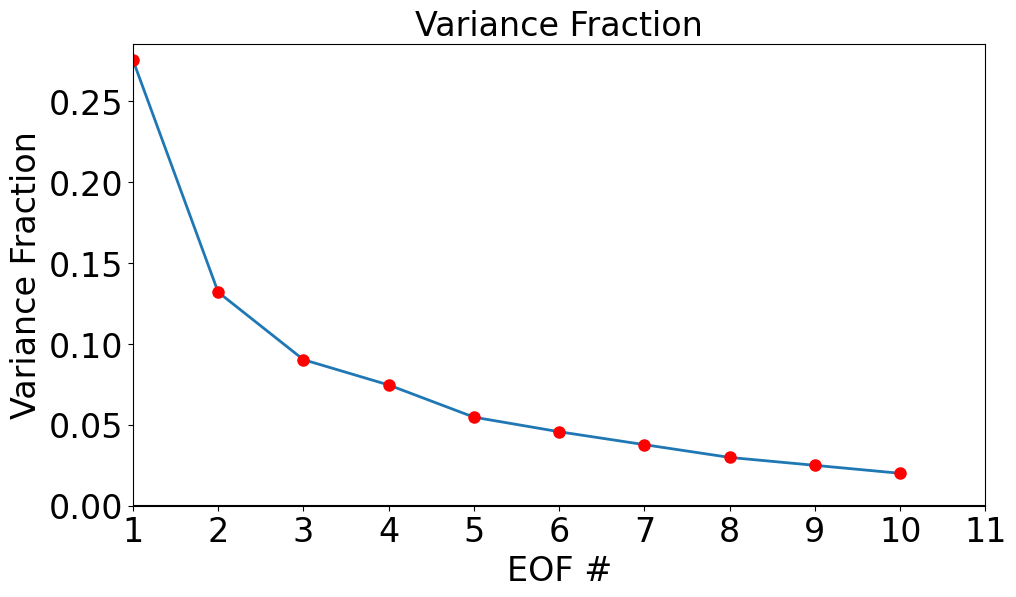

In [25]:
from eofs.standard import Eof
print('Generated')
lat = lat_sst
lon = lon_sst

# Remove all time steps where all values are NaN
sst_data = rollout['sst'].values.squeeze()[:600]  # shape: (time, lat, lon)
# Find time indices where not all values are NaN
valid_time_idx = ~np.all(np.isnan(sst_data), axis=(1, 2))
Data = sst_data[valid_time_idx]

wgts = np.cos(np.deg2rad(lat)).reshape(len(lat), 1)
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(Data, weights=wgts)
eof1 = solver.eofs()

pc=solver.pcs(pcscaling=1)
varfrac=solver.varianceFraction()
lambdas=solver.eigenvalues()


parallels = np.arange(-90,90,20)
meridians = np.arange(-180,180,40)



for i in range(3):
    fig=plt.figure(figsize=(10,16)) 

    m=Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat),
            urcrnrlon=max(lon), urcrnrlat=max(lat), resolution='l')
    x, y = m(*np.meshgrid(lon,lat))
    clevs = np.linspace(-0.1,0.1,11)
    cs = m.contourf(x,y,eof1[i,:,:].squeeze(),clevs,cmap=plt.cm.RdBu_r)
    m.drawcoastlines()
    m.fillcontinents(color='#000000',lake_color='#99ffff')
    
    m.drawparallels(parallels,labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians,labels=[1,0,0,1], fontsize=18)

    cb=m.colorbar(cs, 'bottom', size='5%',pad='10%')
    cb.ax.tick_params(labelsize=24)  # Increase font size of colorbar ticks
    #cb.set_label('EOF', fontsize=10)
    plt.title('EOF '+str(i+1)+', Variance Explained: '+str(round(varfrac[i],3)), fontsize=24)  
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()
    fig=plt.figure(figsize=(10,16))
    plt.subplot(212)
    #days = pd.date_range('1871-01-01', '2011-01-01', freq='ME')
    plt.plot( pc[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.xlabel('Months', fontsize=24)
    plt.ylabel('PC Amplitude', fontsize=24) 
    plt.title('PC Amplitude '+str(i+1), fontsize=24)    
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

    plot=cal_power_spect(pc[:,i])
    plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
    plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
    plt.xscale('log')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=18)
    plt.xlabel('Period (Years)', fontsize=24)
    plt.ylabel('Power', fontsize=24)
    plt.legend(fontsize=16)
    plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

plt.figure(figsize=(11,6))
eof_num = range(1, 11)
plt.plot(eof_num, varfrac[0:10], linewidth=2)
plt.plot(eof_num, varfrac[0:10], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16),fontsize=24)
plt.yticks(fontsize=24)
plt.title('Fraction of the total variance represented by each EOF', fontsize=15)
plt.xlabel('EOF #', fontsize=24)
plt.ylabel('Variance Fraction', fontsize=24)
plt.xlim(1, 11)
plt.ylim(np.min(varfrac), np.max(varfrac)+0.01)
plt.title('Variance Fraction', fontsize=24)  
plt.savefig('temp.png',dpi=300,bbox_inches='tight')
plt.show()

In [ ]:
from scipy.signal import detrend
test_data_norm_detrend = detrend(test_data_norm, axis=0)

In [17]:
ori_test

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 552, lat: 48, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1971-01-01 1971-02-01 ... 2016-12-01
  * lat      (lat) float64 384B -89.5 -85.77 -82.04 -78.31 ... 78.31 82.04 85.77
  * lon      (lon) float64 1kB 0.0 2.493 4.986 7.479 ... 349.0 351.5 354.0 356.5
Data variables:
    sst      (time, lat, lon) float64 31MB -0.8126 -0.8126 ... -0.8137 -0.8137

test data


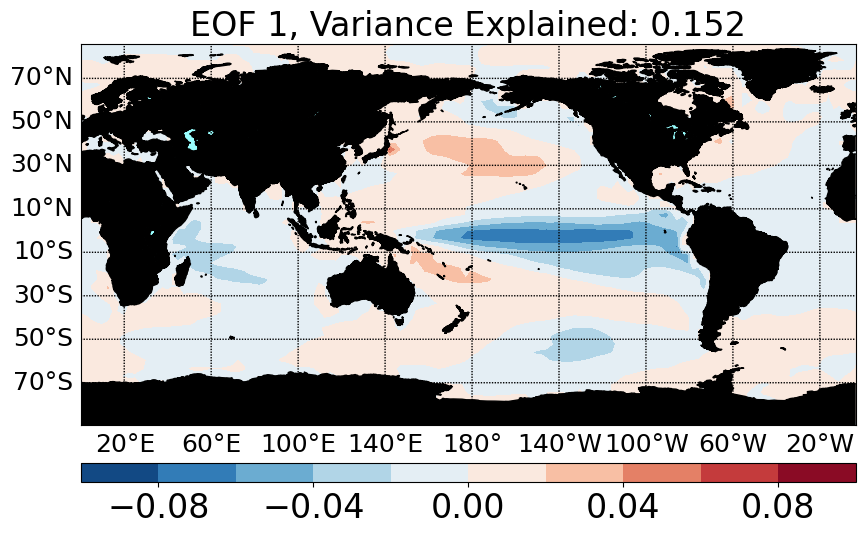

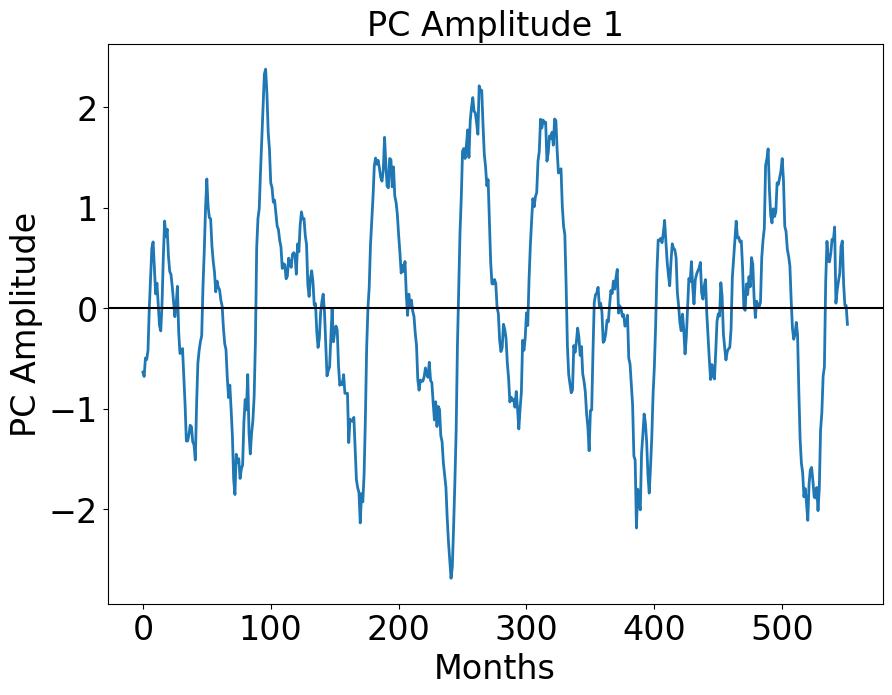

/tmp/ipykernel_1631135/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1631135/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


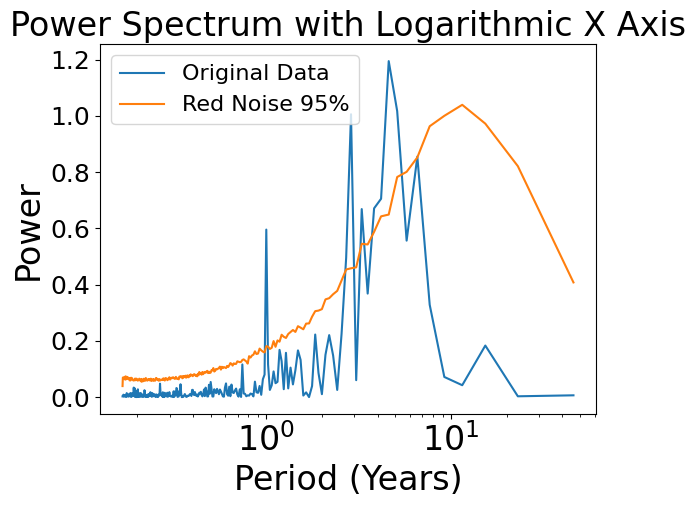

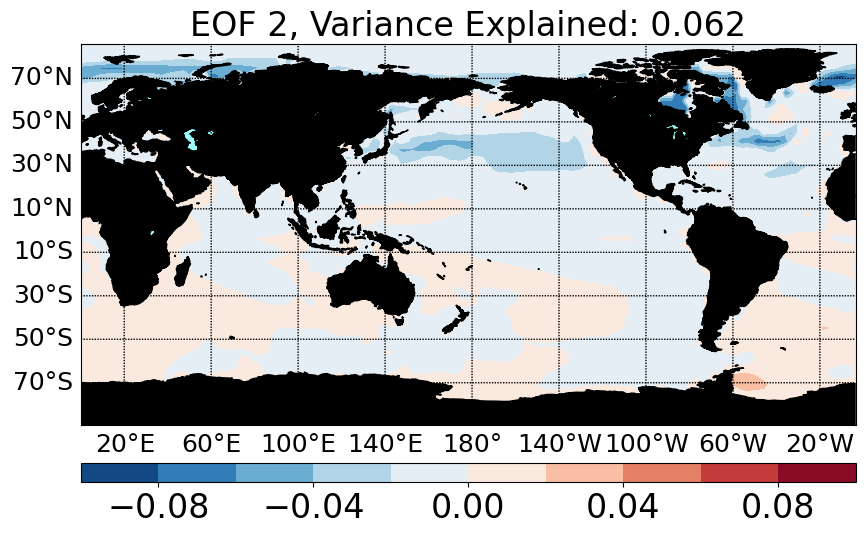

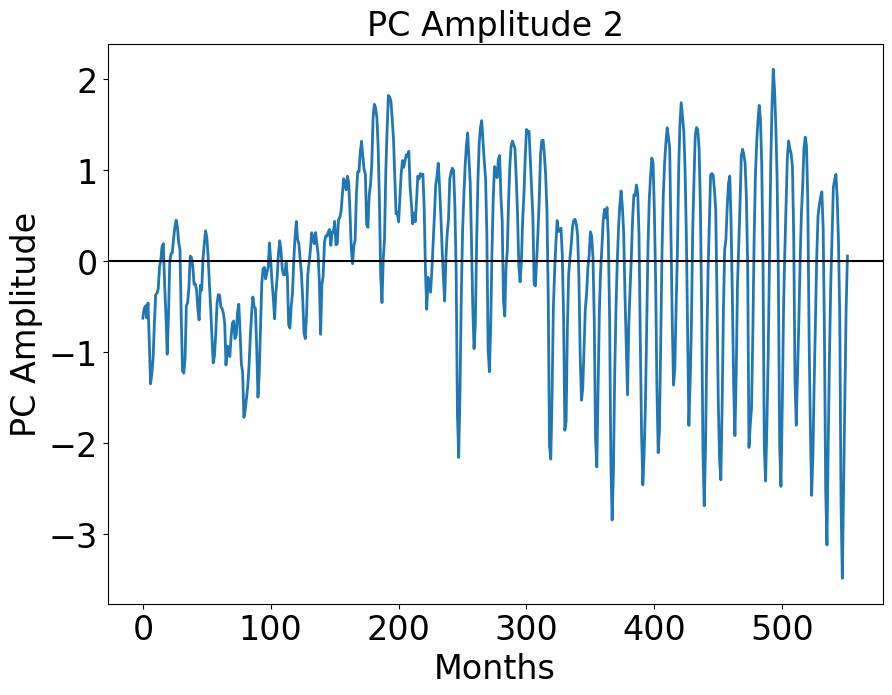

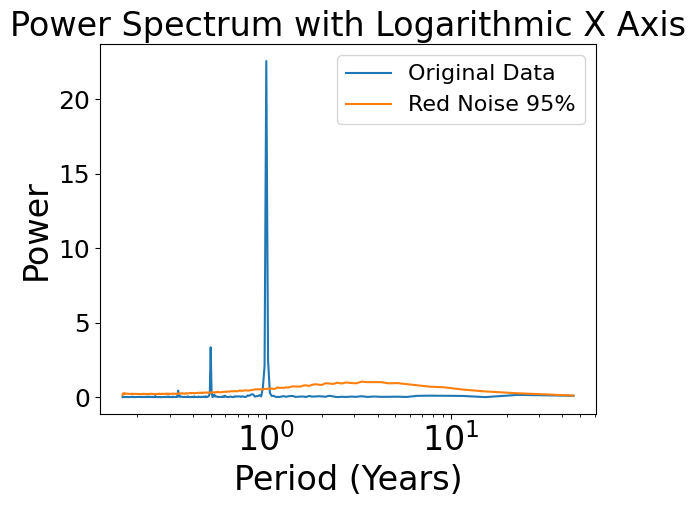

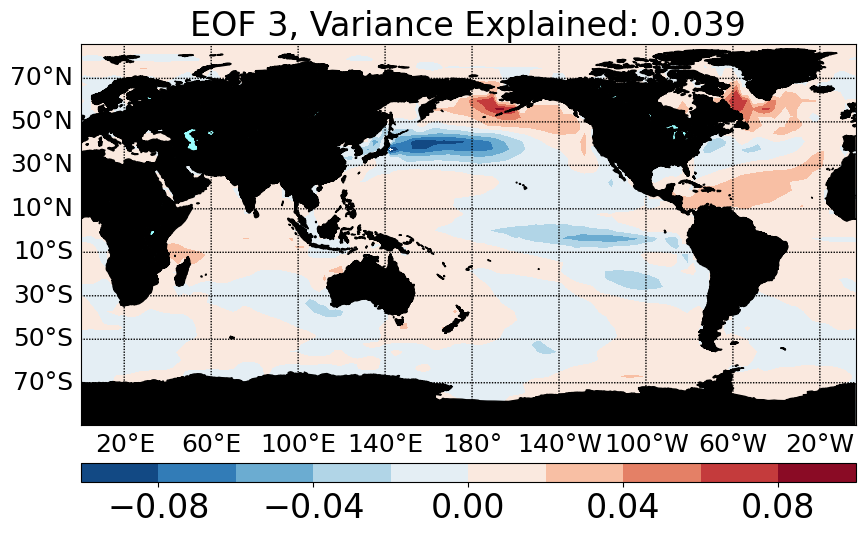

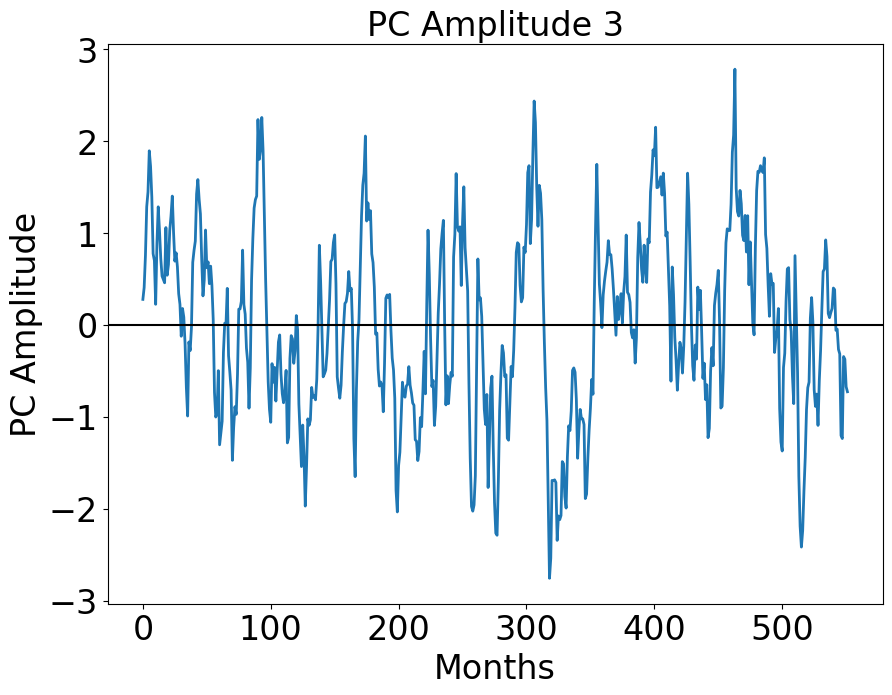

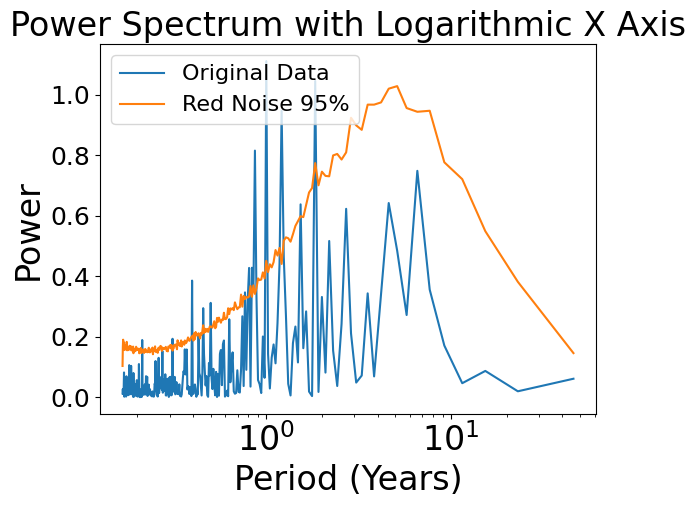

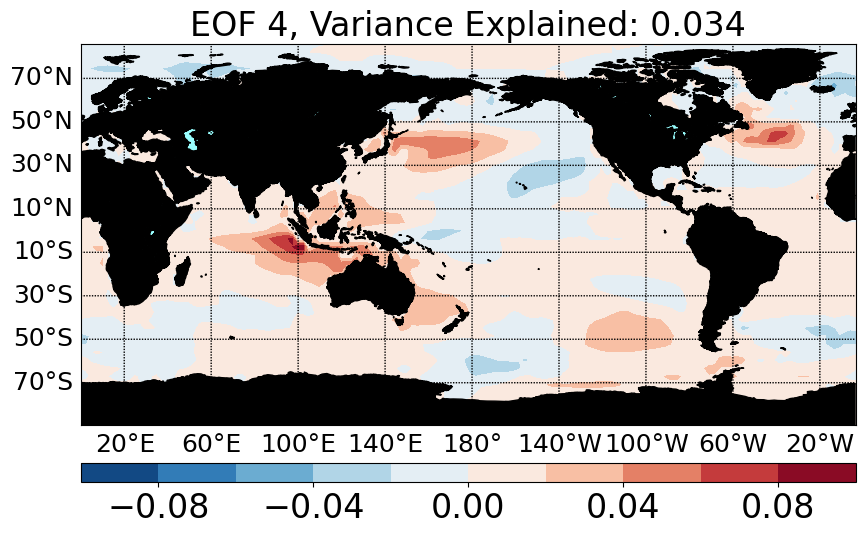

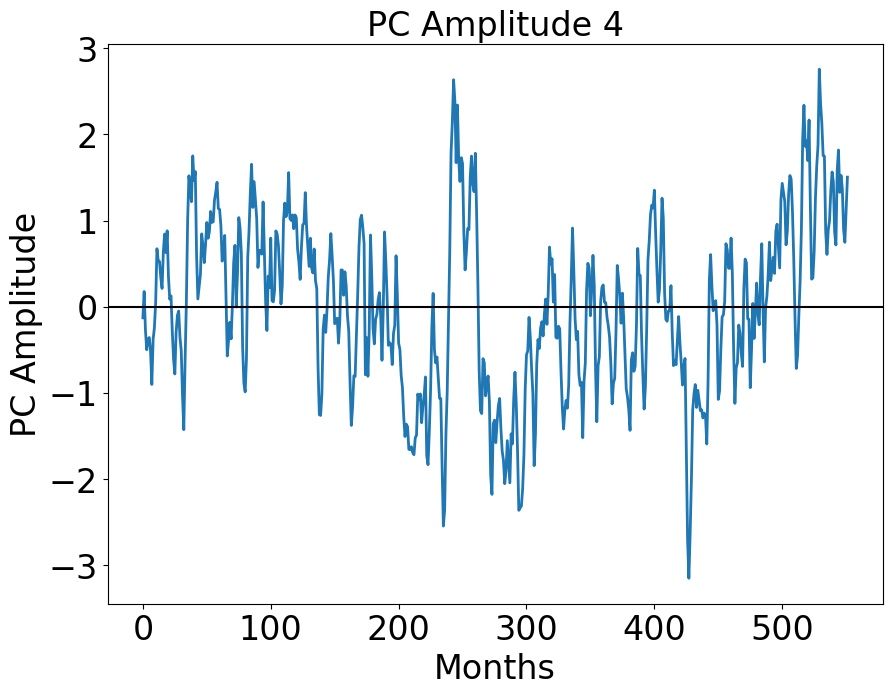

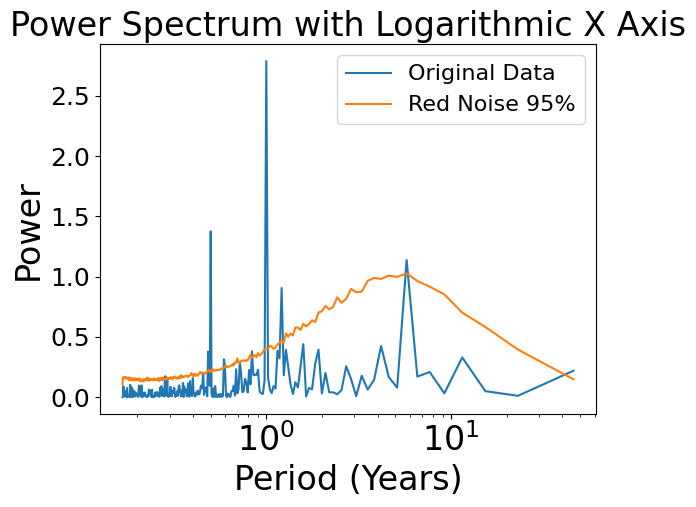

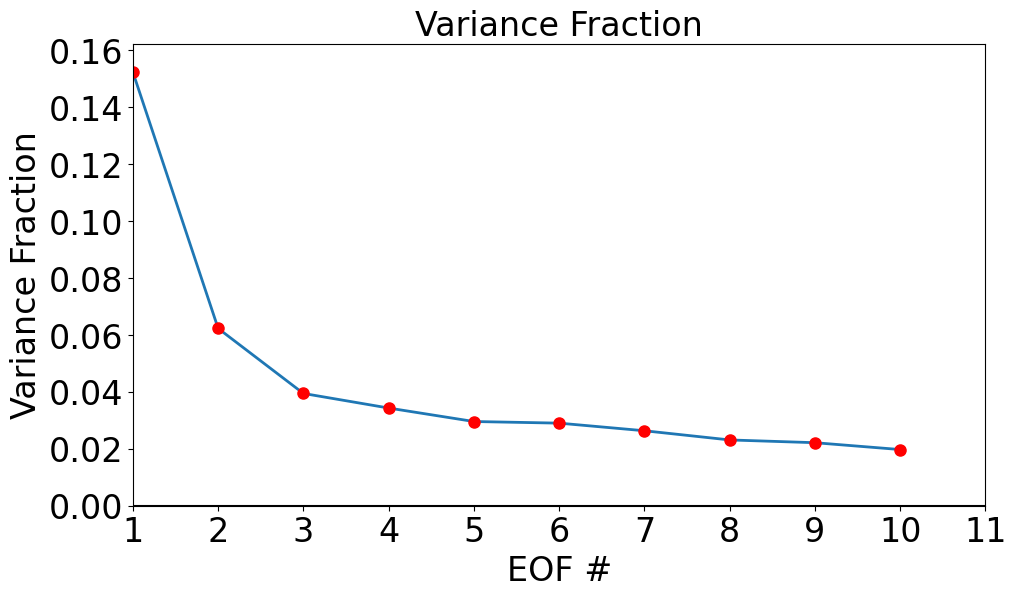

In [45]:
from eofs.standard import Eof
print('test data')
lat = lat_sst
lon = lon_sst

# Remove all time steps where all values are NaN
sst_data = ori_test.sst.values  # shape: (time, lat, lon)
# Find time indices where not all values are NaN
valid_time_idx = ~np.all(np.isnan(sst_data), axis=(1, 2))
Data = sst_data[valid_time_idx]

wgts = np.cos(np.deg2rad(lat)).reshape(len(lat), 1)
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(Data, weights=wgts)
eof1 = solver.eofs()

pc=solver.pcs(pcscaling=1)
varfrac=solver.varianceFraction()
lambdas=solver.eigenvalues()


parallels = np.arange(-90,90,20)
meridians = np.arange(-180,180,40)



for i in range(4):
    fig=plt.figure(figsize=(10,16)) 

    m=Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat),
            urcrnrlon=max(lon), urcrnrlat=max(lat), resolution='l')
    x, y = m(*np.meshgrid(lon,lat))
    clevs = np.linspace(-0.1,0.1,11)
    cs = m.contourf(x,y,eof1[i,:,:].squeeze(),clevs,cmap=plt.cm.RdBu_r)
    m.drawcoastlines()
    m.fillcontinents(color='#000000',lake_color='#99ffff')
    
    m.drawparallels(parallels,labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians,labels=[1,0,0,1], fontsize=18)

    cb=m.colorbar(cs, 'bottom', size='5%',pad='10%')
    cb.ax.tick_params(labelsize=24)  # Increase font size of colorbar ticks
    #cb.set_label('EOF', fontsize=10)
    plt.title('EOF '+str(i+1)+', Variance Explained: '+str(round(varfrac[i],3)), fontsize=24)  
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()
    fig=plt.figure(figsize=(10,16))
    plt.subplot(212)
    #days = pd.date_range('1871-01-01', '2011-01-01', freq='ME')
    plt.plot( pc[:,i], linewidth=2)
    plt.axhline(0, color='k')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.xlabel('Months', fontsize=24)
    plt.ylabel('PC Amplitude', fontsize=24) 
    plt.title('PC Amplitude '+str(i+1), fontsize=24)    
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

    plot=cal_power_spect(pc[:,i])
    plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
    plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
    plt.xscale('log')
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=18)
    plt.xlabel('Period (Years)', fontsize=24)
    plt.ylabel('Power', fontsize=24)
    plt.legend(fontsize=16)
    plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
    plt.savefig('temp.png',dpi=300,bbox_inches='tight')
    plt.show()

plt.figure(figsize=(11,6))
eof_num = range(1, 11)
plt.plot(eof_num, varfrac[0:10], linewidth=2)
plt.plot(eof_num, varfrac[0:10], linestyle='None', marker="o", color='r', markersize=8)
plt.axhline(0, color='k')
plt.xticks(range(1, 16),fontsize=24)
plt.yticks(fontsize=24)
plt.title('Fraction of the total variance represented by each EOF', fontsize=15)
plt.xlabel('EOF #', fontsize=24)
plt.ylabel('Variance Fraction', fontsize=24)
plt.xlim(1, 11)
plt.ylim(np.min(varfrac), np.max(varfrac)+0.01)
plt.title('Variance Fraction', fontsize=24)  
plt.savefig('temp.png',dpi=300,bbox_inches='tight')
plt.show()

In [48]:
ONI_gen=rollout.sel(lat=slice(-5.0,5.0),lon=slice(170,240))['sst'].mean(['lat','lon'])

ONI_ori=ori_test.sel(lat=slice(-5.0,5.0),lon=slice(170,240))['sst'].mean(['lat','lon'])

In [ ]:
# ONI_gen_3mo_avg = ONI_gen.rolling(time=3, center=True).mean().fillna(0)

# ONI_ori_3mo_avg = ONI_ori.rolling(time=3, center=True).mean().fillna(0)

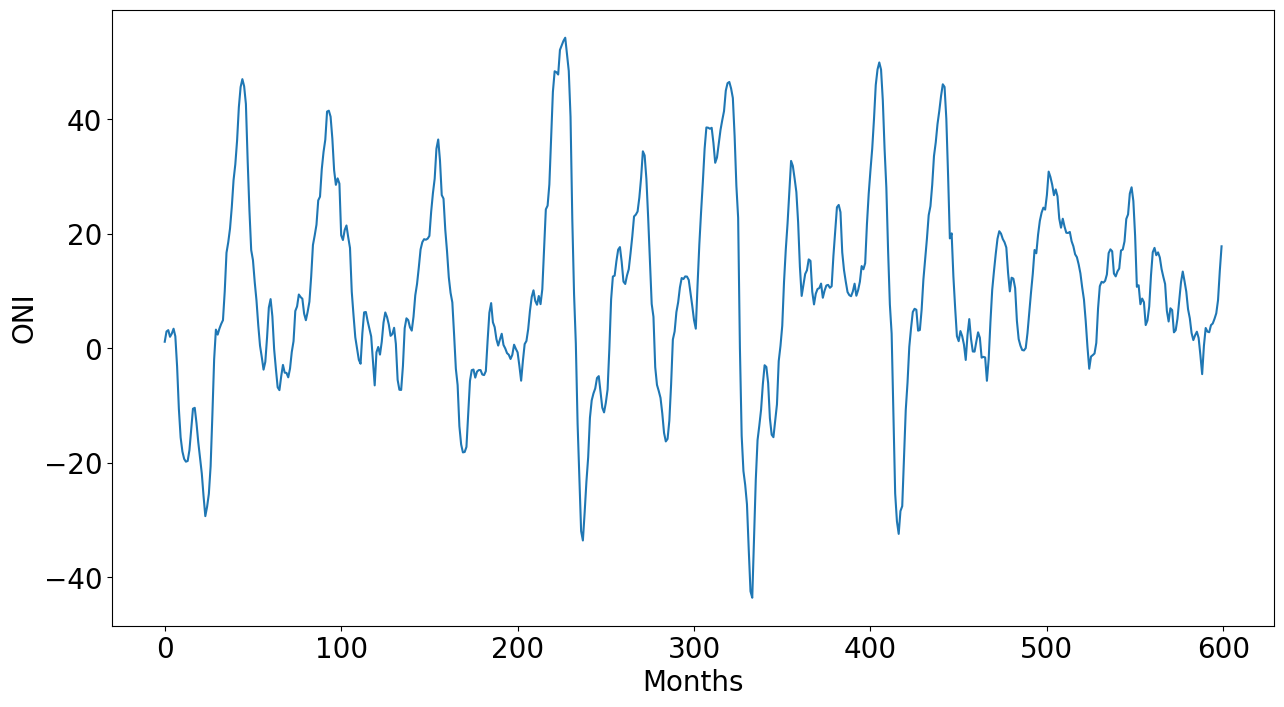

In [49]:
import pandas as pd

f = plt.figure()
f.set_figwidth(15)
f.set_figheight(8)

plt.plot(ONI_gen.values[:600])

#plt.plot(ONI_ori.values.reshape(1980),label='GISS')

plt.xlabel('Months',fontsize=20)
plt.ylabel('ONI',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

#plt.legend()
#plt.title('ENSO Index')
plt.savefig('../../Data/output/EC_Earth3_CC/Updated/ONI_gen.png',dpi=300,bbox_inches='tight')
plt.show()

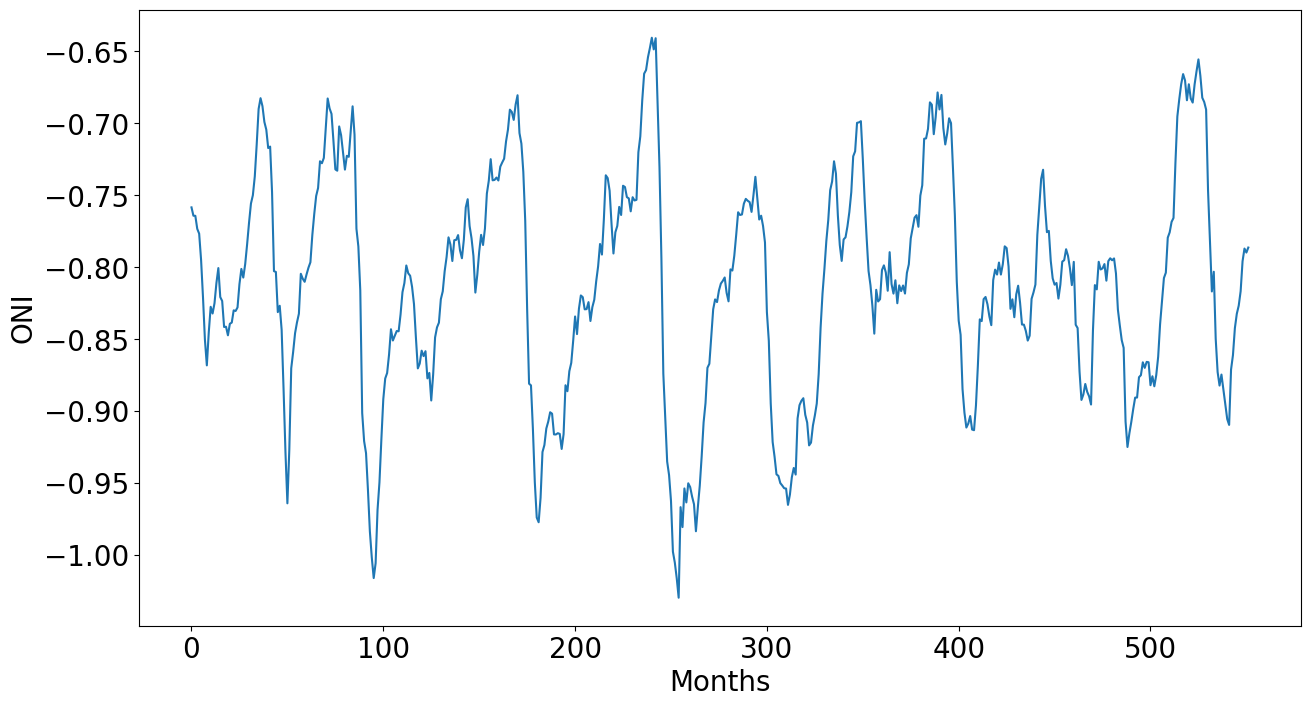

In [32]:
import pandas as pd

f = plt.figure()
f.set_figwidth(15)
f.set_figheight(8)

plt.plot(ONI_ori.values.reshape(552))

#plt.plot(ONI_ori.values.reshape(1980),label='GISS')

plt.xlabel('Months',fontsize=20)
plt.ylabel('ONI',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

#plt.legend()
#plt.title('ENSO Index')
plt.savefig('../../Data/output/EC_Earth3_CC/Updated/ONI_3ma_gen.png',dpi=300,bbox_inches='tight')
plt.show()

/tmp/ipykernel_1631135/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1631135/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


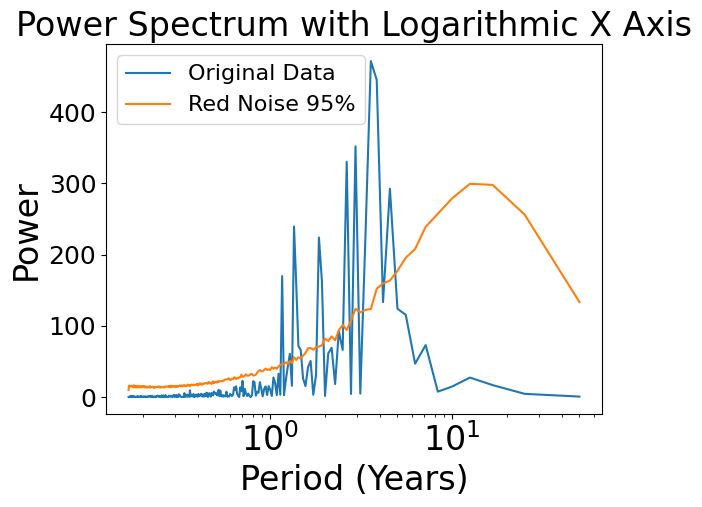

In [50]:
plot=cal_power_spect(ONI_gen.values[:600])
plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
plt.xscale('log')
plt.xticks(fontsize=24)
plt.yticks(fontsize=18)
plt.xlabel('Period (Years)', fontsize=24)
plt.ylabel('Power', fontsize=24)
plt.legend(fontsize=16)
plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
plt.savefig('../../Data/output/EC_Earth3_CC/Updated/ONI_pow_spec_gen.png',dpi=300,bbox_inches='tight')
plt.show()

/tmp/ipykernel_1631135/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1631135/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


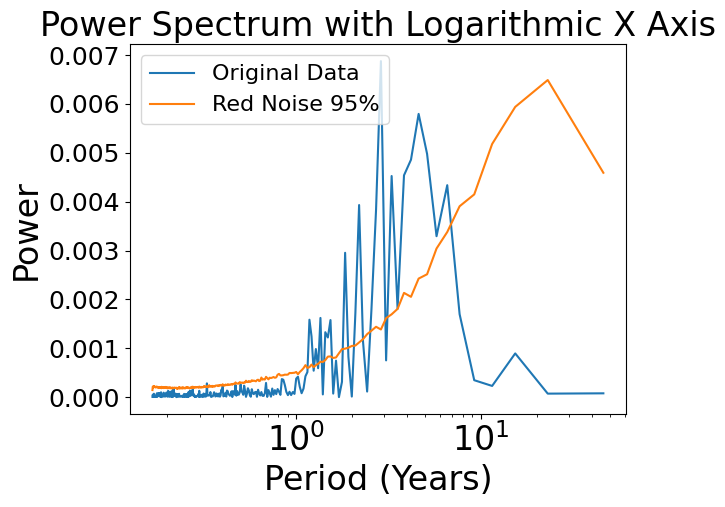

In [36]:
plot=cal_power_spect(ONI_ori.values)
plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
plt.xscale('log')
plt.xticks(fontsize=24)
plt.yticks(fontsize=18)
plt.xlabel('Period (Years)', fontsize=24)
plt.ylabel('Power', fontsize=24)
plt.legend(fontsize=16)
plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
plt.savefig('../../Data/output/EC_Earth3_CC/Updated/ONI_pow_spec_ori.png',dpi=300,bbox_inches='tight')
plt.show()

In [51]:
IODM_gen=rollout.sel(lat=slice(-10.0,10.0),lon=slice(50,70))['sst'].mean(['lat','lon'])-rollout.sel(lat=slice(-10.0,0.0),lon=slice(90,110))['sst'].mean(['lat','lon'])

IODM_ori=ori_test.sel(lat=slice(-10.0,10.0),lon=slice(50,70))['sst'].mean(['lat','lon'])-ori_test.sel(lat=slice(-10.0,0.0),lon=slice(90,110))['sst'].mean(['lat','lon'])

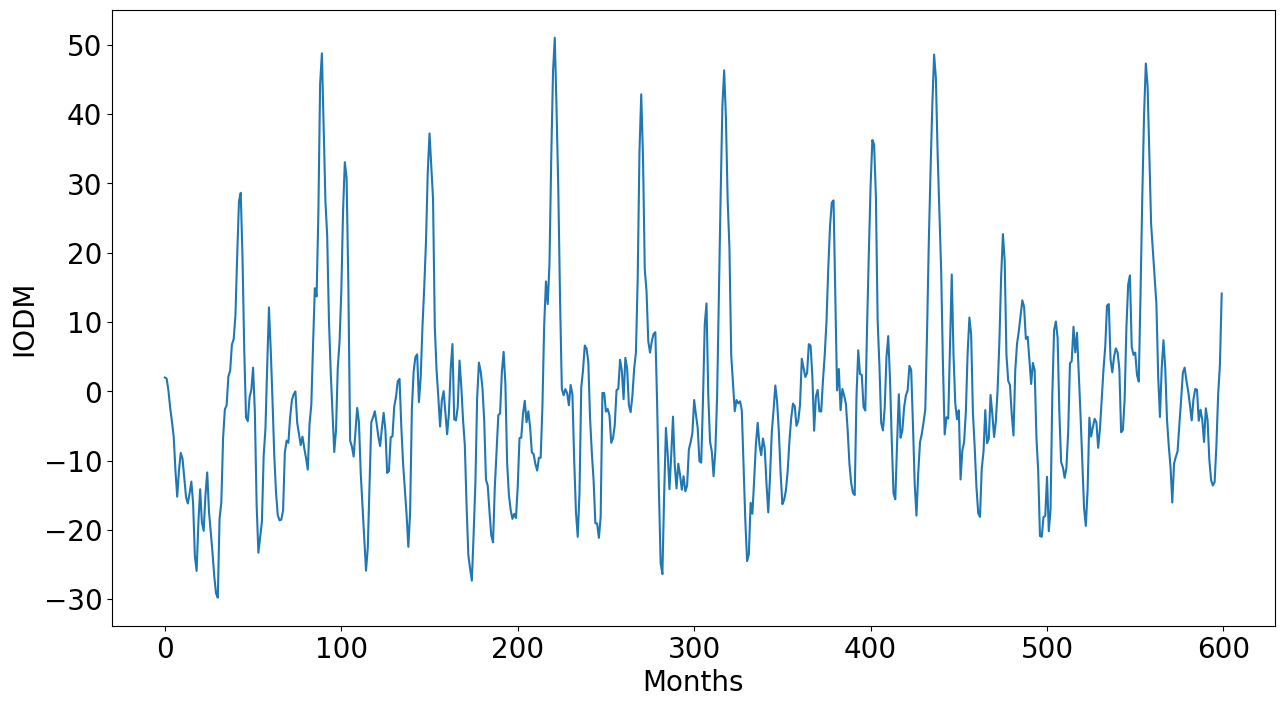

In [52]:
import pandas as pd

f = plt.figure()
f.set_figwidth(15)
f.set_figheight(8)

plt.plot(IODM_gen.values[:600])

#plt.plot(ONI_ori.values.reshape(1980),label='GISS')

plt.xlabel('Months',fontsize=20)
plt.ylabel('IODM',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

#plt.legend()
#plt.title('ENSO Index')
plt.savefig('../../Data/output/EC_Earth3_CC/Updated/IODM_gen.png',dpi=300,bbox_inches='tight')
plt.show()

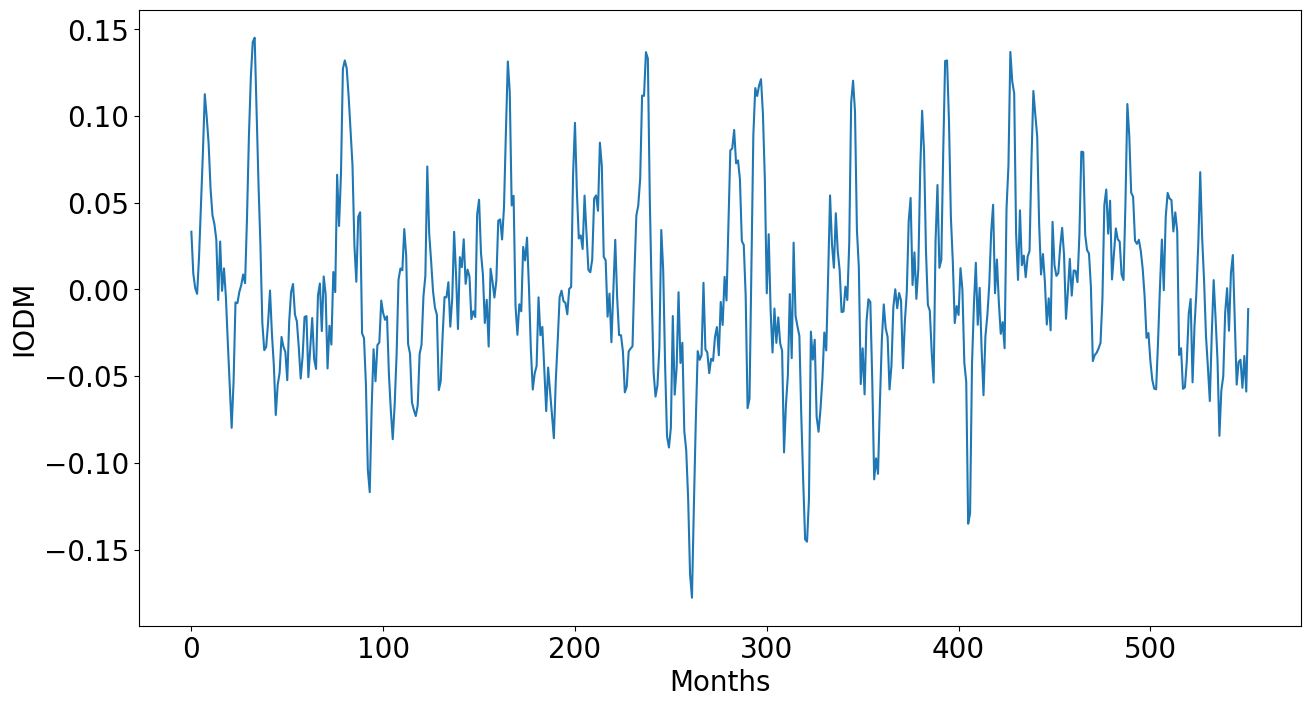

In [46]:
import pandas as pd

f = plt.figure()
f.set_figwidth(15)
f.set_figheight(8)

plt.plot(IODM_ori.values)

#plt.plot(ONI_ori.values.reshape(1980),label='GISS')

plt.xlabel('Months',fontsize=20)
plt.ylabel('IODM',fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

#plt.legend()
#plt.title('ENSO Index')
plt.savefig('../../Data/output/EC_Earth3_CC/Updated/IODM_ori.png',dpi=300,bbox_inches='tight')
plt.show()

/tmp/ipykernel_1631135/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1631135/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


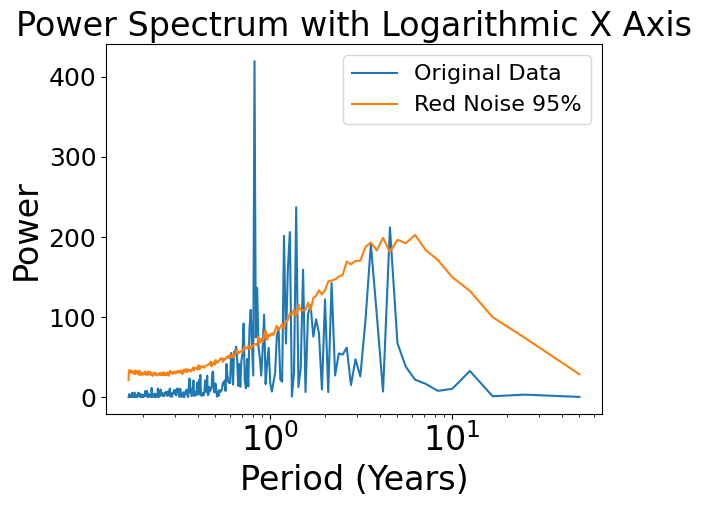

In [53]:
plot=cal_power_spect(IODM_gen.values[:600])
plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
plt.xscale('log')
plt.xticks(fontsize=24)
plt.yticks(fontsize=18)
plt.xlabel('Period (Years)', fontsize=24)
plt.ylabel('Power', fontsize=24)
plt.legend(fontsize=16)
plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
plt.savefig('../../Data/output/EC_Earth3_CC/IODM_pow_spec_gen.png',dpi=300,bbox_inches='tight')
plt.show()

/tmp/ipykernel_1631135/3630853429.py:99: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_1631135/3630853429.py:100: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


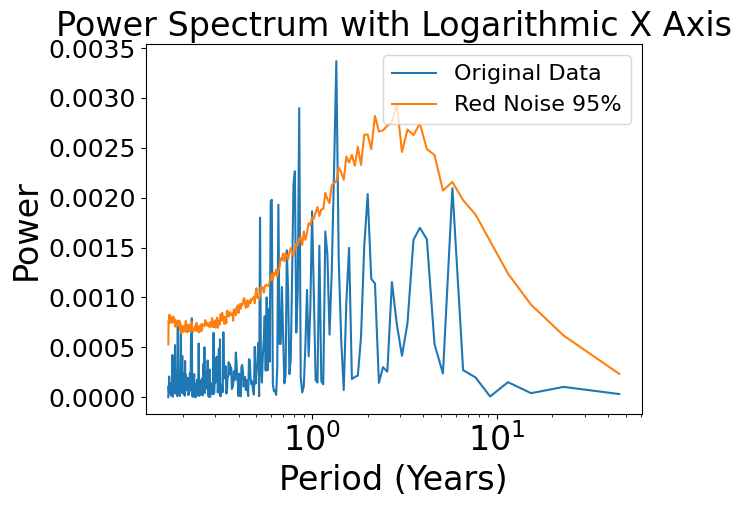

In [42]:
plot=cal_power_spect(IODM_ori.values)
plt.plot(plot[:, 0]/ 12, plot[:, 1], label='Original Data')
plt.plot(plot[:, 0]/ 12, plot[:, 2], label='Red Noise 95%')
plt.xscale('log')
plt.xticks(fontsize=24)
plt.yticks(fontsize=18)
plt.xlabel('Period (Years)', fontsize=24)
plt.ylabel('Power', fontsize=24)
plt.legend(fontsize=16)
plt.title('Power Spectrum with Logarithmic X Axis', fontsize=24)
plt.savefig('../../Data/output/EC_Earth3_CC/IODM_pow_spec_ori.png',dpi=300,bbox_inches='tight')
plt.show()